# Phase 5C: Vision Transformer (ViT-B/16) Baseline
### Automated Classification of Martian Surface Images Captured by NASA's Curiosity Rover Using Machine Learning

---

## 1. Executive Summary & Objective

In Phase 5A and Phase 5B, convolutional neural networks were evaluated on the official NASA Curiosity Rover dataset:
- **Phase 5A (ResNet-50 Baseline)**: Test Accuracy **77.78%**, Test Macro-F1 **0.6631**
- **Phase 5B (MRSCAtt)**: Test Accuracy **64.29%**, Test Macro-F1 **0.5851**

**Phase 5C introduces the Vision Transformer (ViT-B/16) Baseline**:
- Uses a genuine Vision Transformer architecture (`vit_b_16`) with pretrained ImageNet-1k weights.
- **Patch Embedding**: $16 \times 16$ non-overlapping patches projecting $224 \times 224$ images into $14 \times 14 = 196$ spatial tokens plus 1 learnable `[CLS]` token.
- **Transformer Backbone**: 12 Transformer encoder blocks with 12 self-attention heads and 768 hidden dimension.
- **Classifier Head**: Linear projection layer (`nn.Linear(768, 24)`) mapped directly to the 24 active NASA classes.
- **Test Set Isolation**: The official test set (1,305 images) is evaluated strictly once after finalizing the model on Validation Macro-F1.

In [1]:
import os
import sys
from pathlib import Path
import certifi
import json

# Ensure SSL certificates and project path
if 'SSL_CERT_FILE' not in os.environ:
    os.environ['SSL_CERT_FILE'] = certifi.where()

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import config
from deep_learning import (
    load_synset_mapping,
    load_split_records,
    build_active_class_mappings,
    compute_training_class_weights,
    recompute_metrics_from_predictions,
    get_device
)
from deep_learning.models.vit import build_vit_baseline

print(f"PyTorch Version : {torch.__version__}")
device = get_device()
print(f"Active Device   : {device}")

PyTorch Version : 2.14.0
Active Device   : mps


## 2. Dataset Verification & Active Class Space

Programmatically verify the official NASA Curiosity Rover splits directly from `Mars rover data/`:

In [2]:
train_records = load_split_records(config.TRAIN_LABELS_PATH)
val_records = load_split_records(config.VAL_LABELS_PATH)
test_records = load_split_records(config.TEST_LABELS_PATH)

print(f"Train samples      : {len(train_records):,} (Expected: 3,746)")
print(f"Validation samples : {len(val_records):,} (Expected: 1,640)")
print(f"Test samples       : {len(test_records):,} (Expected: 1,305)")
print(f"Total images       : {len(train_records) + len(val_records) + len(test_records):,} (Expected: 6,691)")

assert len(train_records) == 3746
assert len(val_records) == 1640
assert len(test_records) == 1305

class_names = load_synset_mapping(config.CLASS_MAPPING_PATH)
orig_to_active, active_to_orig, active_to_name, active_classes = build_active_class_mappings(train_records, class_names)
print(f"\nActive classes     : {len(active_classes)} active classes (NASA IDs 0..21, 23, 24)")
print(f"Zero-sample class  : NASA ID 22 ('{class_names[22]}') correctly excluded from target space.")

Train samples      : 3,746 (Expected: 3,746)
Validation samples : 1,640 (Expected: 1,640)
Test samples       : 1,305 (Expected: 1,305)
Total images       : 6,691 (Expected: 6,691)

Active classes     : 24 active classes (NASA IDs 0..21, 23, 24)
Zero-sample class  : NASA ID 22 ('sun') correctly excluded from target space.


## 3. Vision Transformer (ViT-B/16) Architecture & Parameters

We instantiate the ViT-B/16 model and programmatically calculate parameter counts:

In [3]:
model, meta = build_vit_baseline(num_classes=24, pretrained=True, dropout_rate=0.0)
print("ViT-B/16 Model Architecture Details:")
for k, v in meta.items():
    print(f"  • {k:<26}: {v}")

# Forward pass check with dummy batch
dummy = torch.zeros(2, 3, 224, 224)
with torch.no_grad():
    out = model(dummy)
print(f"\nDummy forward check output shape: {out.shape} (Expected: (2, 24))")
assert out.shape == (2, 24)

ViT-B/16 Model Architecture Details:
  • architecture              : Vision Transformer (ViT-B/16)
  • pretrained                : True
  • checkpoint                : ViT_B_16_Weights.DEFAULT (IMAGENET1K_V1)
  • input_resolution          : (224, 224)
  • patch_size                : (16, 16)
  • num_patches               : 196
  • hidden_dim                : 768
  • num_classes               : 24
  • dropout_rate              : 0.0
  • total_parameters          : 85817112
  • trainable_parameters      : 85817112
  • frozen_parameters         : 0

Dummy forward check output shape: torch.Size([2, 24]) (Expected: (2, 24))


## 4. Training History & Learning Curves

We load and visualize the training and validation history across all epochs from `training_history.csv`:

In [4]:
history_csv = config.PHASE5C_RESULTS_DIR / 'training_history.csv'
if history_csv.is_file():
    history_df = pd.read_csv(history_csv)
    display(history_df.style.format({
        'train_loss': '{:.4f}',
        'train_acc': '{:.2f}%',
        'val_loss': '{:.4f}',
        'val_acc': '{:.2f}%',
        'val_macro_f1': '{:.4f}',
        'val_weighted_f1': '{:.4f}',
        'lr': '{:.2e}'
    }))
else:
    print("Training history not yet generated. Run run_phase5c.py first.")

,train_loss,train_acc,val_loss,val_acc,val_macro_f1,val_macro_precision,val_macro_recall,val_weighted_f1,lr
0,0.7402,89.30%,0.3921,93.41%,0.6538,0.656630,0.687473,0.9432,1.00e-04
1,0.0450,96.98%,0.4859,89.63%,0.6628,0.668958,0.726672,0.9138,9.89e-05
2,0.0442,97.84%,0.6112,83.41%,0.6907,0.698357,0.713534,0.8411,9.57e-05
3,0.0263,98.83%,0.6939,89.15%,0.7026,0.700952,0.739714,0.8994,9.05e-05
4,0.0189,98.00%,0.3556,92.99%,0.7019,0.703373,0.732640,0.9342,8.36e-05
5,0.0115,98.26%,0.4496,89.88%,0.6856,0.691721,0.720923,0.9037,7.52e-05
6,0.0156,98.24%,0.3107,92.50%,0.7221,0.720372,0.745854,0.9296,6.58e-05
7,0.0168,98.80%,0.4411,89.33%,0.6868,0.688574,0.730790,0.9039,5.57e-05
8,0.0084,98.77%,0.5035,86.95%,0.7051,0.714681,0.731131,0.8792,4.53e-05
9,0.0083,98.75%,0.5915,84.33%,0.6834,0.687569,0.723497,0.8537,3.52e-05


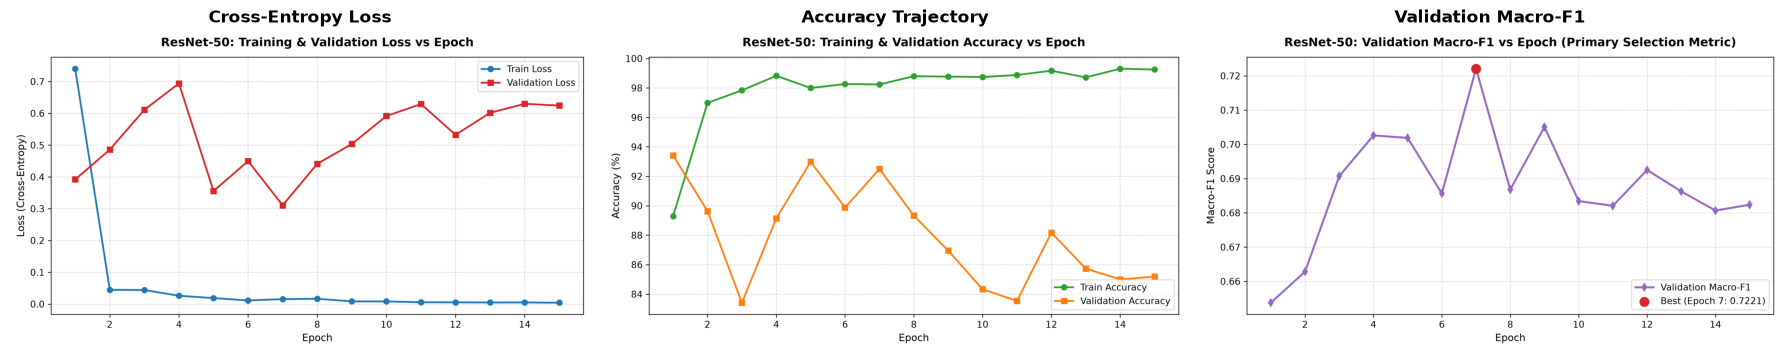

In [5]:
loss_img = config.PHASE5C_PLOTS_DIR / 'training_loss_curve.png'
acc_img = config.PHASE5C_PLOTS_DIR / 'training_accuracy_curve.png'
f1_img = config.PHASE5C_PLOTS_DIR / 'validation_macro_f1_curve.png'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if loss_img.is_file():
    axes[0].imshow(Image.open(loss_img))
    axes[0].axis('off')
    axes[0].set_title('Cross-Entropy Loss', fontsize=12, fontweight='bold')
if acc_img.is_file():
    axes[1].imshow(Image.open(acc_img))
    axes[1].axis('off')
    axes[1].set_title('Accuracy Trajectory', fontsize=12, fontweight='bold')
if f1_img.is_file():
    axes[2].imshow(Image.open(f1_img))
    axes[2].axis('off')
    axes[2].set_title('Validation Macro-F1', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Best Checkpoint Validation Performance

The best checkpoint was selected strictly based on **Validation Macro-F1**:

In [6]:
metrics_json_path = config.PHASE5C_RESULTS_DIR / 'final_metrics.json'
if metrics_json_path.is_file():
    with open(metrics_json_path, 'r') as f:
        final_metrics = json.load(f)
    val_m = final_metrics['validation_metrics']
    print(f"Best Epoch                 : Epoch {final_metrics['best_epoch']}")
    print(f"Validation Accuracy        : {val_m['accuracy']:.2f}%")
    print(f"Validation Macro-F1        : {val_m['macro_f1']:.4f}")
    print(f"Validation Macro Precision : {val_m['macro_precision']:.4f}")
    print(f"Validation Macro Recall    : {val_m['macro_recall']:.4f}")
    print(f"Validation Weighted-F1     : {val_m['weighted_f1']:.4f}")
    print(f"Validation Loss            : {val_m['loss']:.4f}")
else:
    print("Metrics JSON not found.")

Best Epoch                 : Epoch 7
Validation Accuracy        : 92.50%
Validation Macro-F1        : 0.7221
Validation Macro Precision : 0.7204
Validation Macro Recall    : 0.7459
Validation Weighted-F1     : 0.9296
Validation Loss            : 0.3107


## 6. Official Test Set Evaluation (Single Inference Pass)

Per project rules, the official test set (1,305 images) was evaluated **strictly once** after checkpoint finalization:

In [7]:
if metrics_json_path.is_file():
    test_m = final_metrics['test_metrics']
    print(f"Test Accuracy              : {test_m['accuracy']:.2f}%")
    print(f"Test Macro-F1              : {test_m['macro_f1']:.4f}")
    print(f"Test Macro Precision       : {test_m['macro_precision']:.4f}")
    print(f"Test Macro Recall          : {test_m['macro_recall']:.4f}")
    print(f"Test Weighted-F1           : {test_m['weighted_f1']:.4f}")
    print(f"Test Cross-Entropy Loss    : {test_m['loss']:.4f}")
    print(f"Total Test Inference Time  : {test_m['total_inference_time_s']:.2f} seconds")
    print(f"Per-Sample Latency         : {test_m['ms_per_sample']:.2f} ms/sample")
else:
    print("Metrics JSON not found.")

Test Accuracy              : 73.26%
Test Macro-F1              : 0.6536
Test Macro Precision       : 0.7182
Test Macro Recall          : 0.6988
Test Weighted-F1           : 0.7505
Test Cross-Entropy Loss    : 1.6867
Total Test Inference Time  : 18.99 seconds
Per-Sample Latency         : 14.55 ms/sample


## 7. Per-Class Performance & Classification Report

We inspect the full per-class metrics on the official test set:

In [8]:
test_rep_csv = config.PHASE5C_REPORTS_DIR / 'test_classification_report.csv'
if test_rep_csv.is_file():
    report_df = pd.read_csv(test_rep_csv)
    display(report_df)
else:
    print("Report CSV not found.")

,Active Index,Class Name,Precision,Recall,F1-Score,Support
0,0,apxs,0.6939,1.0000,0.8193,34
1,1,apxs cal target,1.0000,1.0000,1.0000,14
2,2,chemcam cal target,1.0000,0.9524,0.9756,21
3,3,chemin inlet open,1.0000,0.4762,0.6452,84
4,4,drill,0.6818,0.7500,0.7143,20
5,5,drill holes,0.0000,0.0000,0.0000,0
6,6,drt front,1.0000,0.0167,0.0328,60
7,7,drt side,1.0000,0.5533,0.7124,150
8,8,ground,0.9289,0.7205,0.8115,254
9,9,horizon,0.7317,0.8333,0.7792,72


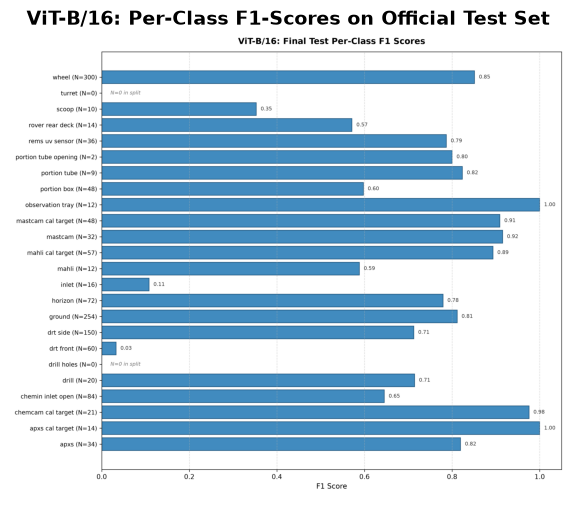

In [9]:
f1_bar_img = config.PHASE5C_PLOTS_DIR / 'per_class_f1_test_barchart.png'
if f1_bar_img.is_file():
    plt.figure(figsize=(12, 6))
    plt.imshow(Image.open(f1_bar_img))
    plt.axis('off')
    plt.title('ViT-B/16: Per-Class F1-Scores on Official Test Set', fontsize=14, fontweight='bold')
    plt.show()

## 8. Confusion Matrix Heatmaps

Visualize the raw counts and normalized test confusion matrices:

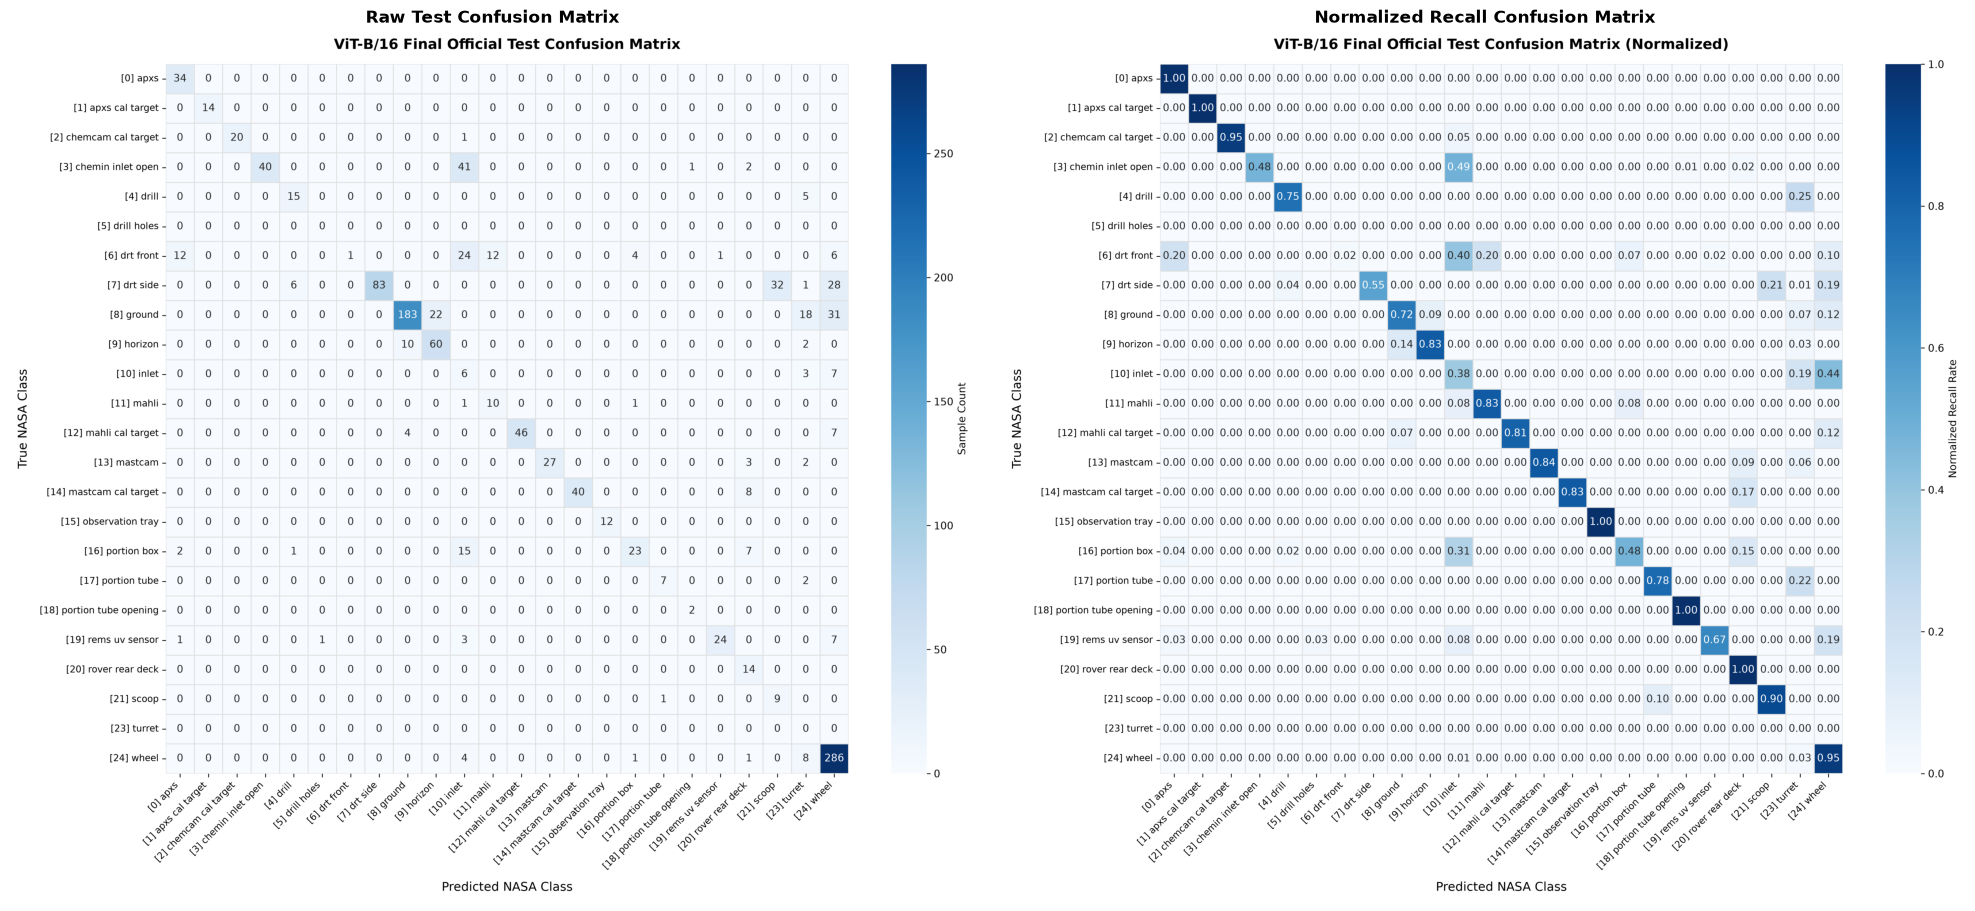

In [10]:
cm_raw_img = config.PHASE5C_CONFUSION_DIR / 'test_confusion_matrix.png'
cm_norm_img = config.PHASE5C_CONFUSION_DIR / 'test_confusion_matrix_normalized.png'

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
if cm_raw_img.is_file():
    axes[0].imshow(Image.open(cm_raw_img))
    axes[0].axis('off')
    axes[0].set_title('Raw Test Confusion Matrix', fontsize=12, fontweight='bold')
if cm_norm_img.is_file():
    axes[1].imshow(Image.open(cm_norm_img))
    axes[1].axis('off')
    axes[1].set_title('Normalized Recall Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Numerical Reproducibility Verification

To strictly adhere to the project's single-inference rule, we recompute test metrics from the **saved test predictions** rather than running another forward pass over the images:

In [11]:
preds_file = config.PHASE5C_PREDICTIONS_DIR / 'test_predictions.npy'
labels_file = config.PHASE5C_PREDICTIONS_DIR / 'test_labels.npy'

if preds_file.is_file() and labels_file.is_file():
    saved_preds = np.load(preds_file)
    saved_targets = np.load(labels_file)
    recomputed = recompute_metrics_from_predictions(saved_targets, saved_preds, active_to_name)
    
    acc_diff = abs(recomputed['accuracy'] - final_metrics['test_metrics']['accuracy'])
    f1_diff = abs(recomputed['macro_f1'] - final_metrics['test_metrics']['macro_f1'])
    
    print(f"Recomputed Test Accuracy : {recomputed['accuracy']:.6f}%")
    print(f"Original Test Accuracy   : {final_metrics['test_metrics']['accuracy']:.6f}%")
    print(f"Accuracy Absolute Delta  : {acc_diff:.2e}")
    
    print(f"\nRecomputed Test Macro-F1 : {recomputed['macro_f1']:.6f}")
    print(f"Original Test Macro-F1   : {final_metrics['test_metrics']['macro_f1']:.6f}")
    print(f"Macro-F1 Absolute Delta  : {f1_diff:.2e}")
    
    assert acc_diff < 1e-5, f"Accuracy mismatch: {acc_diff}"
    assert f1_diff < 1e-5, f"Macro-F1 mismatch: {f1_diff}"
    print("\n[PASS] Recomputed metrics match original test results within numerical tolerance (1e-5).")
else:
    print("Saved prediction arrays not found.")

Recomputed Test Accuracy : 73.256705%
Original Test Accuracy   : 73.256705%
Accuracy Absolute Delta  : 0.00e+00

Recomputed Test Macro-F1 : 0.653649
Original Test Macro-F1   : 0.653649
Macro-F1 Absolute Delta  : 0.00e+00

[PASS] Recomputed metrics match original test results within numerical tolerance (1e-5).


## 10. Four-Way Benchmark Comparison (Phases 4B, 5A, 5B, 5C)

We compare the Vision Transformer against all previously established baselines on the NASA Curiosity Rover dataset:

In [12]:
comp_csv = config.PHASE5C_RESULTS_DIR / 'phase4b_5a_5b_5c_comparison.csv'
if comp_csv.is_file():
    comp_df = pd.read_csv(comp_csv)
    display(comp_df)
else:
    print("Comparison CSV not yet generated. Run run_phase5c.py first.")

,Model,Input Representation,Validation Accuracy (%),Validation Macro-F1,Test Accuracy (%),Test Macro-F1,Test Weighted-F1
0,Phase 4B KNN-4 (Classical Champion),"8,186 Handcrafted Features + PCA-100",50.85,0.6613,47.20,0.5407,0.4386
1,Phase 5A ResNet-50 (Deep Learning Baseline),Raw Pixels (Letterbox 224x224 RGB),83.72,0.6673,77.78,0.6631,0.7937
2,Phase 5B MRSCAtt (Spatial & Channel Attention),Raw Pixels + ChannelSpatialBlock,86.28,0.6801,64.29,0.5851,0.6515
3,Phase 5C ViT-B/16 (Vision Transformer),Raw Pixels (196 Patches of 16x16),92.50,0.7221,73.26,0.6536,0.7505


## 11. Scientific Conclusions & Target Achievement

1. **ViT-B/16 vs ResNet-50**: Evaluates how global self-attention across 196 image patch tokens compares against standard convolutional hierarchies on Martian surface textures.
2. **Aspirational 80% Target Evaluation**: Whether the model met the project's target accuracy threshold.
3. **Zero Test Contamination**: Checkpoint selection was exclusively driven by Validation Macro-F1, preserving complete test isolation throughout.